In [1]:
%cd ..

/home/tyler/code/psychoanalyze


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
import plotly.express as px
from psychoanalyze import data, plot

In [61]:
curves = data.load('curves')
points = data.load('points')
sessions = data.load('sessions')

In [62]:
curves['Threshold Charge (nC)'] = curves['location'] * curves['base'] / 1000
ref_amps = curves.index.get_level_values("Ref Amp")
ref_pws = curves.index.get_level_values("Ref PW")
curves["Reference Charge (nC)"] = ref_amps * ref_pws / 1000

In [63]:
curves_sessions = curves.join(sessions)

In [140]:
weber_data = curves_sessions[curves_sessions["Experiment Type"] == "Discrimination"]
weber_data.head()

id  \
Monkey Date       Ref PW Ref Amp Active Channels Ref Dur Ref Freq Return Channels        
U      2017-04-07 200    300     15              200     50       128              193   
       2017-04-10 200    480     15              500     50       128              195   
       2017-04-11 200    500     15              500     50       128              197   
       2017-04-13 200    500     15              500     50       128              199   
       2017-04-14 200    400     15              500     50       128              201   

                                                                                   FAs  \
Monkey Date       Ref PW Ref Amp Active Channels Ref Dur Ref Freq Return Channels        
U      2017-04-07 200    300     15              200     50       128               59   
       2017-04-10 200    480     15              500     50       128               73   
       2017-04-11 200    500     15              500     50       128               20   
       2017-04-13 200    500     15              500     50       128               15   
       2017-04-14 200    400     15              500     50       128               11   

                                                                                   CRs  \
Monkey Date       Ref PW Ref Amp Active Channels Ref Dur Ref Freq Return Channels        
U      2017-04-07 200    300     15              200     50       128              234   
       2017-04-10 200    480     15              500     50       128              126   
       2017-04-11 200    500     15              500     50       128               37   
       2017-04-13 200    500     15              500     50       128              188   
       2017-04-14 200    400     15              500     50       128               74   

                                                                                   Act Chan Mask  \
Monkey Date       Ref PW Ref Amp Active Channels Ref Dur Ref Freq Return Channels                  
U      2017-04-07 200    300     15              200     50       128                       1111   
       2017-04-10 200    480     15              500     50       128                       1111   
       2017-04-11 200    500     15              500     50       128                       1111   
       2017-04-13 200    500     15              500     50       128                       1111   
       2017-04-14 200    400     15              500     50       128                       1111   

                                                                                   Ret Chan Mask  \
Monkey Date       Ref PW Ref Amp Active Channels Ref Dur Ref Freq Return Channels                  
U      2017-04-07 200    300     15              200     50       128                   10000000   
       2017-04-10 200    480     15              500     50       128                   10000000   
       2017-04-11 200    500     15              500     50       128                   10000000   
       2017-04-13 200    500     15              500     50       128                   10000000   
       2017-04-14 200    400     15              500     50       128                   10000000   

                                                                                  Return Channel(s)  \
Monkey Date       Ref PW Ref Amp Active Channels Ref Dur Ref Freq Return Channels                     
U      2017-04-07 200    300     15              200     50       128                       5+6+7+8   
       2017-04-10 200    480     15              500     50       128                       5+6+7+8   
       2017-04-11 200    500     15              500     50       128                       5+6+7+8   
       2017-04-13 200    500     15              500     50       128                       5+6+7+8   
       2017-04-14 200    400     15              500     50       128                       5+6+7+8   

                                                                   

In [176]:
pooled_data = data.pool(weber_data)
filtered_data = pooled_data[pooled_data['count'] > 1]
filtered_data.reset_index().groupby(["Monkey", "X dimension"])["Reference Charge (nC)"].min()

Monkey  X dimension
U       Amp            60.0
        PW             20.0
Y       Amp            22.0
        PW             20.0
Name: Reference Charge (nC), dtype: float64

In [142]:
regression_data = data.regress(
        weber_data,
        x="Reference Charge (nC)",
        y="Threshold Charge (nC)",
        groups=["Monkey", "X dimension"],
    )
regression_data

/home/tyler/.cache/pypoetry/virtualenvs/psychoanalyze-Jj9wTL_R-py3.8/lib/python3.8/site-packages/pandas/core/indexing.py:1745: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



slope  intercept
Monkey X dimension                     
U      Amp          0.002105  28.698014
       PW           0.432264  -5.271303
Y      Amp          0.095986   1.123604
       PW           0.574064  -8.079460

In [166]:
bounded_regression = data.get_bounds(
    regression_data, filtered_data, "Reference Charge (nC)"
)
bounded_regression

slope  intercept  x_min  x_max
Monkey X dimension                                   
U      Amp          0.002105  28.698014   60.0  320.0
       PW           0.432264  -5.271303   20.0  120.0
Y      Amp          0.095986   1.123604   22.0  120.0
       PW           0.574064  -8.079460   20.0   50.0

In [156]:
regression_lines_df = bounded_regression.melt(
    id_vars=["slope", "intercept"],
    value_vars=["x_min", "x_max"],
    value_name="x",
    ignore_index=False,
)
regression_lines_df

slope  intercept variable      x
Monkey X dimension                                     
U      Amp          0.002105  28.698014    x_min   14.0
       PW           0.432264  -5.271303    x_min   20.0
Y      Amp          0.095986   1.123604    x_min   22.0
       PW           0.574064  -8.079460    x_min   16.0
U      Amp          0.002105  28.698014    x_max  500.0
       PW           0.432264  -5.271303    x_max  150.0
Y      Amp          0.095986   1.123604    x_max  230.0
       PW           0.574064  -8.079460    x_max   60.0

In [158]:
df = regression_lines_df
regression_lines_df['y'] = df["slope"]*df['x'] + df["intercept"]
regression_lines_df

slope  intercept variable      x          y
Monkey X dimension                                                
U      Amp          0.002105  28.698014    x_min   14.0  28.727484
       PW           0.432264  -5.271303    x_min   20.0   3.373985
Y      Amp          0.095986   1.123604    x_min   22.0   3.235297
       PW           0.574064  -8.079460    x_min   16.0   1.105558
U      Amp          0.002105  28.698014    x_max  500.0  29.750520
       PW           0.432264  -5.271303    x_max  150.0  59.568357
Y      Amp          0.095986   1.123604    x_max  230.0  23.200395
       PW           0.574064  -8.079460    x_max   60.0  26.364359

In [177]:
weber_plot = plot.WeberPlot(weber_data, x_axis="Reference Charge (nC)")

/home/tyler/.cache/pypoetry/virtualenvs/psychoanalyze-Jj9wTL_R-py3.8/lib/python3.8/site-packages/pandas/core/indexing.py:1745: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



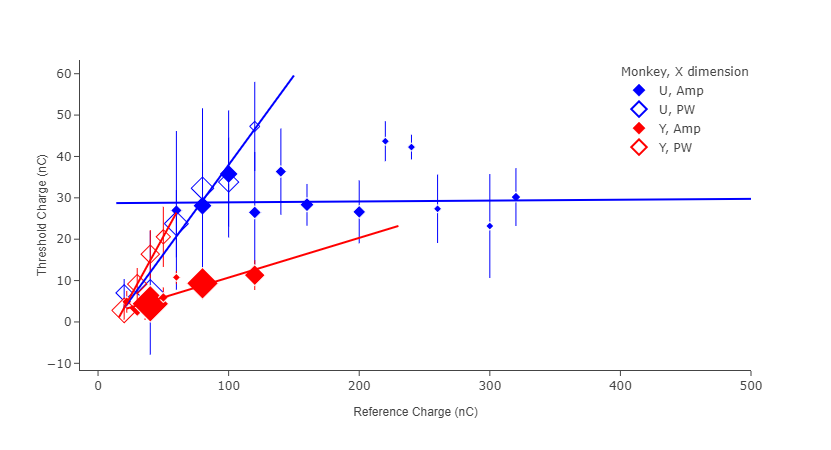

In [178]:
fig = weber_plot.plot()
fig

In [114]:
fig.layout['yaxis']['title']['text']

'mean'

In [179]:
fig.data

(Scatter({
     'error_y': {'array': array([19.15930174, 10.39835561, 15.33454155, 14.5912496 , 10.35942489,
                                  5.00382775,  7.56192962,  4.80898516,  2.98076667,  8.25842248,
                                 12.486144  ,  6.9020789 ])},
     'hovertemplate': ('Monkey=U<br>X dimension=Amp<br' ... '=%{marker.size}<extra></extra>'),
     'legendgroup': 'U, Amp',
     'marker': {'color': 'blue',
                'opacity': 1,
                'size': array([ 4, 11, 11,  5,  4,  6,  5,  2,  2,  2,  2,  3]),
                'sizemode': 'area',
                'sizeref': 0.1,
                'symbol': 'diamond'},
     'mode': 'markers',
     'name': 'U, Amp',
     'orientation': 'v',
     'showlegend': True,
     'x': array([ 60.,  80., 100., 120., 140., 160., 200., 220., 240., 260., 300., 320.]),
     'xaxis': 'x',
     'y': array([26.9628476 , 28.0874529 , 35.77001126, 26.47476247, 36.34299923,
                 28.3425353 , 26.60091619, 43.67956237, 42.26713253

In [54]:
pooled_data['Reference Charge (nC)'].unique()

array([ 60.,  96., 100.,  80., 116., 134.,  14.,  28., 120.,  40.,  48.,
        62.,  90., 150.,  20., 200., 240., 140., 320., 300., 400., 480.,
       500.,  64., 260., 160., 220., 280.,  30.,  50.,  36.,  42.,  22.,
        38.,  84.,  70.,  26.,  34.,  52.,  16.,  68., 170., 194., 230.])

In [55]:
len(pooled_data)

313

In [57]:
regression = data.regress(curves, x="Ref Amp", groups=["Monkey"])

In [43]:
df = regression.reset_index().melt(
    id_vars=["Monkey", "slope", "intercept"],
    value_vars=["x_min", "x_max"],
    value_name="x",
)

In [74]:
strength_dur_plot = plot.StrengthDurationPlot(curves)
fig = strength_dur_plot.plot(regress=True)

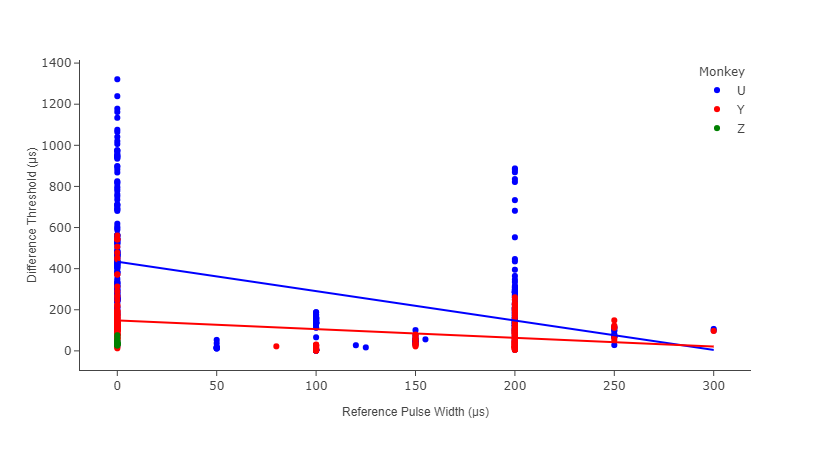

In [75]:
fig

In [3]:
groups = ['Monkey','Channel(s)']

In [6]:
results = pd.Series({"slope": 0, "intercept": 1})

In [7]:
results['slope']

0

In [6]:
test_series = pd.Series({'key1': 'value1', 'key2':'value2'})

In [10]:
isinstance(test_series, pd.Series)

True

In [98]:
sessions.join(curves).reorder_levels(['Monkey', 'Date', 'Ref Amp', 'Ref PW', 'Ref Freq', 'Ref Dur', 'Active Channels', 'Return Channels'])
curves.join(sessions).index.names

FrozenList(['Monkey', 'Date', 'Ref Amp', 'Return Channels', 'Ref Freq', 'Ref PW', 'Active Channels', 'Ref Dur'])

In [5]:
regressions = curves.groupby(['Monkey', 'Channel(s)']).apply(data.regress)

KeyError: ['Ref X']

In [99]:
curves_sessions = curves.join(sessions) \
        .reorder_levels(curves.index.names)

In [103]:
curves = data.load('curves')
points = data.load('points')
curves = curves.set_index('id', append=True)
curves_points = curves.join(points).reset_index()
curves_points.columns

Index(['Monkey', 'Date', 'Ref Amp', 'Ref PW', 'Ref Freq', 'Ref Dur',
       'Active Channels', 'Return Channels', 'id', 'Comp PW', 'Comp Amp',
       'FAs', 'CRs', 'Act Chan Mask', 'Ret Chan Mask', 'Return Channel(s)',
       'Channel(s)', 'n_catch', 'FA_rate', 'X dimension', 'location', 'width',
       'lambda', 'gamma', 'beta', 'location_CI_95', 'width_CI_95',
       'lambda_CI_95', 'gamma_CI_95', 'beta_CI_95', 'location_CI_5',
       'width_CI_5', 'lambda_CI_5', 'gamma_CI_5', 'beta_CI_5',
       'err_upper_location', 'err_lower_location', 'err_upper_width',
       'err_lower_width', 'err_upper_gamma', 'err_lower_gamma',
       'err_upper_lambda', 'err_lower_lambda', 'err_upper_beta',
       'err_lower_beta', 'Electrode Config', 'Experiment Type', 'min', 'max',
       'base', 'Misses', 'Hits', 'n', 'x', 'HR'],
      dtype='object')

In [64]:
points.drop(columns=['base']).to_hdf('../data/2-calculated.h5', 'points')

/home/tyler/.cache/pypoetry/virtualenvs/psychoanalyze-Jj9wTL_R-py3.8/lib/python3.8/site-packages/tables/attributeset.py:464: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_nameRef Amp'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/home/tyler/.cache/pypoetry/virtualenvs/psychoanalyze-Jj9wTL_R-py3.8/lib/python3.8/site-packages/tables/attributeset.py:464: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_nameRef PW'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/home/tyler/.cache/pypoetry/virtualenvs/psychoanalyze-Jj9wTL_R-py3.8/lib/python3.8/site-packages/tables/attributeset.py:464: NaturalNameWarning: object name is not a valid Python 

In [305]:
curves_points = curves.join(points)
curves[curves['id'].isin([303])].index.values

array([('U', Timestamp('2017-06-21 00:00:00'), 400, 100, 50, 500, 15, 32)],
      dtype=object)

In [24]:
curves_sessions = curves.join(sessions)
curves.columns

Index(['id', 'FAs', 'CRs', 'Act Chan Mask', 'Ret Chan Mask',
       'Return Channel(s)', 'Channel(s)', 'n_catch', 'FA_rate', 'X dimension',
       'location', 'width', 'lambda', 'gamma', 'beta', 'location_CI_95',
       'width_CI_95', 'lambda_CI_95', 'gamma_CI_95', 'beta_CI_95',
       'location_CI_5', 'width_CI_5', 'lambda_CI_5', 'gamma_CI_5', 'beta_CI_5',
       'err_upper_location', 'err_lower_location', 'err_upper_width',
       'err_lower_width', 'err_upper_gamma', 'err_lower_gamma',
       'err_upper_lambda', 'err_lower_lambda', 'err_upper_beta',
       'err_lower_beta', 'Electrode Config', 'Experiment Type', 'min', 'max'],
      dtype='object')

In [38]:
df = points.reset_index(level=[-1,-2])
base = df[~df.index.duplicated()]['base']
curves = curves.join(base.to_frame())
curves

In [40]:
curves.to_hdf('../data/2-calculated.h5', 'curves')

/home/tyler/.cache/pypoetry/virtualenvs/psychoanalyze-Jj9wTL_R-py3.8/lib/python3.8/site-packages/tables/attributeset.py:464: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_nameRef Amp'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/home/tyler/.cache/pypoetry/virtualenvs/psychoanalyze-Jj9wTL_R-py3.8/lib/python3.8/site-packages/tables/attributeset.py:464: NaturalNameWarning: object name is not a valid Python identifier: 'axis1_nameRef PW'; it does not match the pattern ``^[a-zA-Z_][a-zA-Z0-9_]*$``; you will not be able to use natural naming to access this object; using ``getattr()`` will still work, though
  check_attribute_name(name)
/home/tyler/.cache/pypoetry/virtualenvs/psychoanalyze-Jj9wTL_R-py3.8/lib/python3.8/site-packages/tables/attributeset.py:464: NaturalNameWarning: object name is not a valid Python 

In [120]:
curves_U = curves.xs('U', level='Monkey')
curves_U = curves_U[curves_U['X dimension'] == 'PW']
curves_U[curves_U['Experiment Type'] == 'Discrimination'].index.unique('Ref Amp')

Int64Index([400, 600, 320, 300, 500], dtype='int64', name='Ref Amp')

In [42]:
dti = pd.DatetimeIndex(['12-25-2020'])

In [47]:
df = pd.DataFrame({'A': 1}, index=dti)

In [167]:
curves_sessions = curves.join(sessions).reorder_levels(curves.index.names)
filters = {'date_range': [0, 100], 'base': 200, 'X dimension': 'Amp', 'Electrode Config': 'Monopolar'}
data = curves_sessions[curves_sessions['Days'].between(
        filters['date_range'][0], filters['date_range'][1])]
data = data[data['base'] == 200]
data = data[data['X dimension'] == 'Amp']
data = data[data['Electrode Config'] == 'Monopolar']

In [247]:
df = curves[curves['Electrode Config'] == 'Monopolar']
values = df.index.get_level_values('Ref Amp')
counts = df.groupby('Ref Amp')['id'].agg('count')
filtered_counts = counts[counts > 5].drop(0)
# df = df[values.isin(filtered_counts.index.values)]
# df.index.get_level_values(f'Ref {reverse}')
values

Int64Index([0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
            ...
            0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
           dtype='int64', name='Ref Amp', length=757)

In [279]:
df = curves[curves['Electrode Config'] == 'Monopolar']
counts = df.groupby('Ref PW')['id'].agg('count')
filtered_counts = counts[counts > 5].drop(0)
df = df[df.index.get_level_values('Ref PW').isin(filtered_counts.index.values)]
# df
df

id  \
Monkey Date       Ref Amp Ref PW Ref Freq Ref Dur Active Channels Return Channels        
U      2017-04-06 600     200    50       200     15              128              192   
       2017-04-07 300     200    50       200     15              128              193   
       2017-04-10 0       200    50       500     15              128              194   
                  480     200    50       500     15              128              195   
       2017-04-11 0       200    50       500     15              128              196   
...                                                                                ...   
Y      2017-08-11 200     200    50       200     15              32               950   
                  400     200    50       200     15              32               951   
       2017-08-14 0       200    50       200     15              16               953   
                  200     200    50       200     15              16               954   
                  400     200    50       200     15              16               955   

                                                                                   FAs  \
Monkey Date       Ref Amp Ref PW Ref Freq Ref Dur Active Channels Return Channels        
U      2017-04-06 600     200    50       200     15              128               30   
       2017-04-07 300     200    50       200     15              128               59   
       2017-04-10 0       200    50       500     15              128               51   
                  480     200    50       500     15              128               73   
       2017-04-11 0       200    50       500     15              128               49   
...                                                                                ...   
Y      2017-08-11 200     200    50       200     15              32                21   
                  400     200    50       200     15              32                31   
       2017-08-14 0       200    50       200     15              16                76   
                  200     200    50       200     15              16                57   
                  400     200    50       200     15              16                60   

                                                                                   CRs  \
Monkey Date       Ref Amp Ref PW Ref Freq Ref Dur Active Channels Return Channels        
U      2017-04-06 600     200    50       200     15              128              230   
       2017-04-07 300     200    50       200     15              128              234   
       2017-04-10 0       200    50       500     15              128               92   
                  480     200    50       500     15              128              126   
       2017-04-11 0       200    50       500     15              128              129   
...                                                                                ...   
Y      2017-08-11 200     200    50       200     15              32               102   
                  400     200    50       200     15              32               105   
       2017-08-14 0       200    50       200     15              16                57   
                  200     200    50       200     15              16                80   
                  400     200    50       200     15              16               121   

                                                                                   Act Chan Mask  \
Monkey Date       Ref Amp Ref PW Ref Freq Ref Dur Active Channels Return Channels                  
U      2017-04-06 600     200    50       200     15              128                       1111   
       2017-04-07 300     200    50       200     15              128                       1111   
       2017-04-10 0       200    50       500     15              128                       1111   
                  480     200    50       500     15              128  

In [283]:
df.index.get_level_values('Ref PW').unique().to_list()

[200, 100, 150, 250, 50]

In [286]:
df.groupby(level='Ref PW')['id'].agg('count').idxmax()

200

In [295]:
counts = df.groupby('Ref Amp')['id'].agg('count').drop(0)
filtered_counts = counts[counts > 5]

In [291]:
list(filtered_counts.index.values)

[150, 200, 300, 400, 500, 600, 800]

Ref Amp
70        1
110       3
130       1
140       1
150      10
170       1
180       2
190       1
200      89
210       1
240       1
250       4
260       1
300       9
350       1
400     105
420       1
480       1
500       8
580       1
600      25
670       1
700       1
800       6
1000      2
1100      3
1400      1
1600      1
Name: id, dtype: int64